# Video: Object Detection Fundamentals

The following is a recording on this topic, I hope you find it useful!  

Feel free to watch at 1.5x or 2x speed.

**Note**: If you find something missing or incorrect in the recording, then please let me know! 

<video id="myVideo" width="700" height="500" controls="controls" preload="none">
  <source src="video.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

<script>
    document.getElementById('myVideo').addEventListener('loadedmetadata', function() {
        this.playbackRate = 1.5;
    });
</script>

# Object Detection Fundamentals

- Understand the fundamental concepts of object detection
- Differentiate between object detection, classification, and segmentation
- Learn about key architectures in modern object detection
- Explore evaluation metrics for object detection models


## Image Classification

:::: {.columns}
::: {.column width="45%"}

- Image classification is the task of predicting the class label of an image
- The output is a single class label for the entire image
- The model is trained on a dataset of images and their corresponding class labels
- Images with multiple objects can only be classified as one class

:::

::: {.column width="55%"}
![](./img/classification.png){width=100%}
:::
::::


## Object Detection

- Object detection is the task of predicting the class label and bounding box of an object in an image
- The output is a list of class labels and bounding boxes for each object in the image
- The model is trained on a dataset of images and their corresponding class labels and bounding boxes

![](./img/object-detection.png){width=100%}


## Semantic Segmentation

- Semantic segmentation is the task of predicting or creating an output image mask (mask)
- The mask contains a channel which corresponds to each class label
    - And each pixel's probability of belonging to that class
    - The mask chanel with the highest probability is the predicted class label for that pixel

![](./img/semantic-segmentation.png){width=90%}


## Instance Segmentation

- Instance segmentation combines semantic segmentation and object detection
- A combination of bounding boxes and segmentation masks creates the final output


![](./img/instance-segmentation.png){width=90%}

# Object Detection Fundamentals

Object detection is a computer vision task that involves:

- Localizing objects within an image (finding where they are)
- Classifying each detected object (determining what they are)
- Outputting bounding boxes and class labels with confidence scores

### Key Challenges:

- Scale variation
- Occlusion
- Viewpoint variation
- Background clutter



## Deep Learning Object Detection

:::: {.columns}
::: {.column width="50%"}

Two-Stage Detectors:

Includes region proposal and classification steps

1. R-CNN Family:
   - R-CNN (2014)
   - Fast R-CNN (2015)
   - Faster R-CNN (2015)
   - Mask R-CNN (2017)

:::
::: {.column width="50%"}

Single-Stage Detectors:

Single forward pass through the network

1. YOLO Family:
   - YOLOv1 (2016)
   - YOLOv2/YOLO9000 (2017)
   - YOLOv3 (2018)
   - YOLOv4-v8 (2020-2023)
2. SSD (Single Shot Detector)
3. RetinaNet

:::
::::


## Two-Stage Detectors vs Single-Stage Detectors

| Feature                     | Single-Stage Detectors         | Two-Stage Detectors                   |
|-----------------------------|--------------------------------|---------------------------------------|
| **Speed**                   | Faster; processes in one step  | Slower; processes in two steps        |
| **Complexity**              | Simpler architecture           | More complex architecture             |
| **Accuracy**                | Generally lower accuracy       | Higher accuracy                       |
| **Use Cases**               | Real-time applications         | Applications requiring high precision |
| **Examples**                | YOLO, SSD                      | R-CNN, Faster R-CNN                   |

## Components of a Two-Stage Detector

1. Backbone Network (Feature Extraction)
2. Region Proposal Network (RPN)
3. RoI Pooling
4. Classification and Bounding Box Regression

*YOLO Architecture* (for comparison):

1. Single Neural Network
2. Grid-based Predictions
3. Anchor Boxes
4. Multi-scale Feature Maps

## Intersection Over Union
:::: {.columns}
::: {.column width="45%"}

![](./img/iou.png){width=80%}

:::

::: {.column width="55%"}

- Intersection over Union (IoU) is a metric used to evaluate the performance of object detection models
- It is the ratio of the intersection area to the union area of two bounding boxes
- IoU is used to determine if a predicted bounding box is a true positive, false positive, or false negative

:::
::::


# Selective Search

1. **Initial Segmentation**  
   - The image is divided into small regions using a fast segmentation algorithm (e.g., Felzenszwalb’s segmentation).  
   
2. **Feature Extraction for Region Merging**  
   - Each segmented region is described by features such as color, texture, size, and shape similarity.  

3. **Hierarchical Region Merging**  
   - Similar regions are iteratively merged based on a similarity metric that combines color, texture, size, and spatial proximity.  
   - This results in a hierarchical grouping, generating larger regions over multiple iterations.  

4. **Generation of Region Proposals**  
   - A diverse set of potential object regions (bounding boxes) is extracted from different hierarchical levels.  

5. **Filtering and Ranking**  
   - The proposals are ranked based on their likelihood of containing objects, and redundant or low-confidence proposals are discarded.  

6. **Forwarding Proposals to R-CNN**  
   - The selected region proposals are resized and passed to a CNN for feature extraction, followed by classification and bounding box regression.

## Selective Search Example {.scrollable}

- Selective Search is a region proposal method used in object detection
- It generates a set of bounding boxes for an image
- The bounding boxes are generated by recursively merging regions with similar color and texture
- Selective Search is the first step in region based object detection

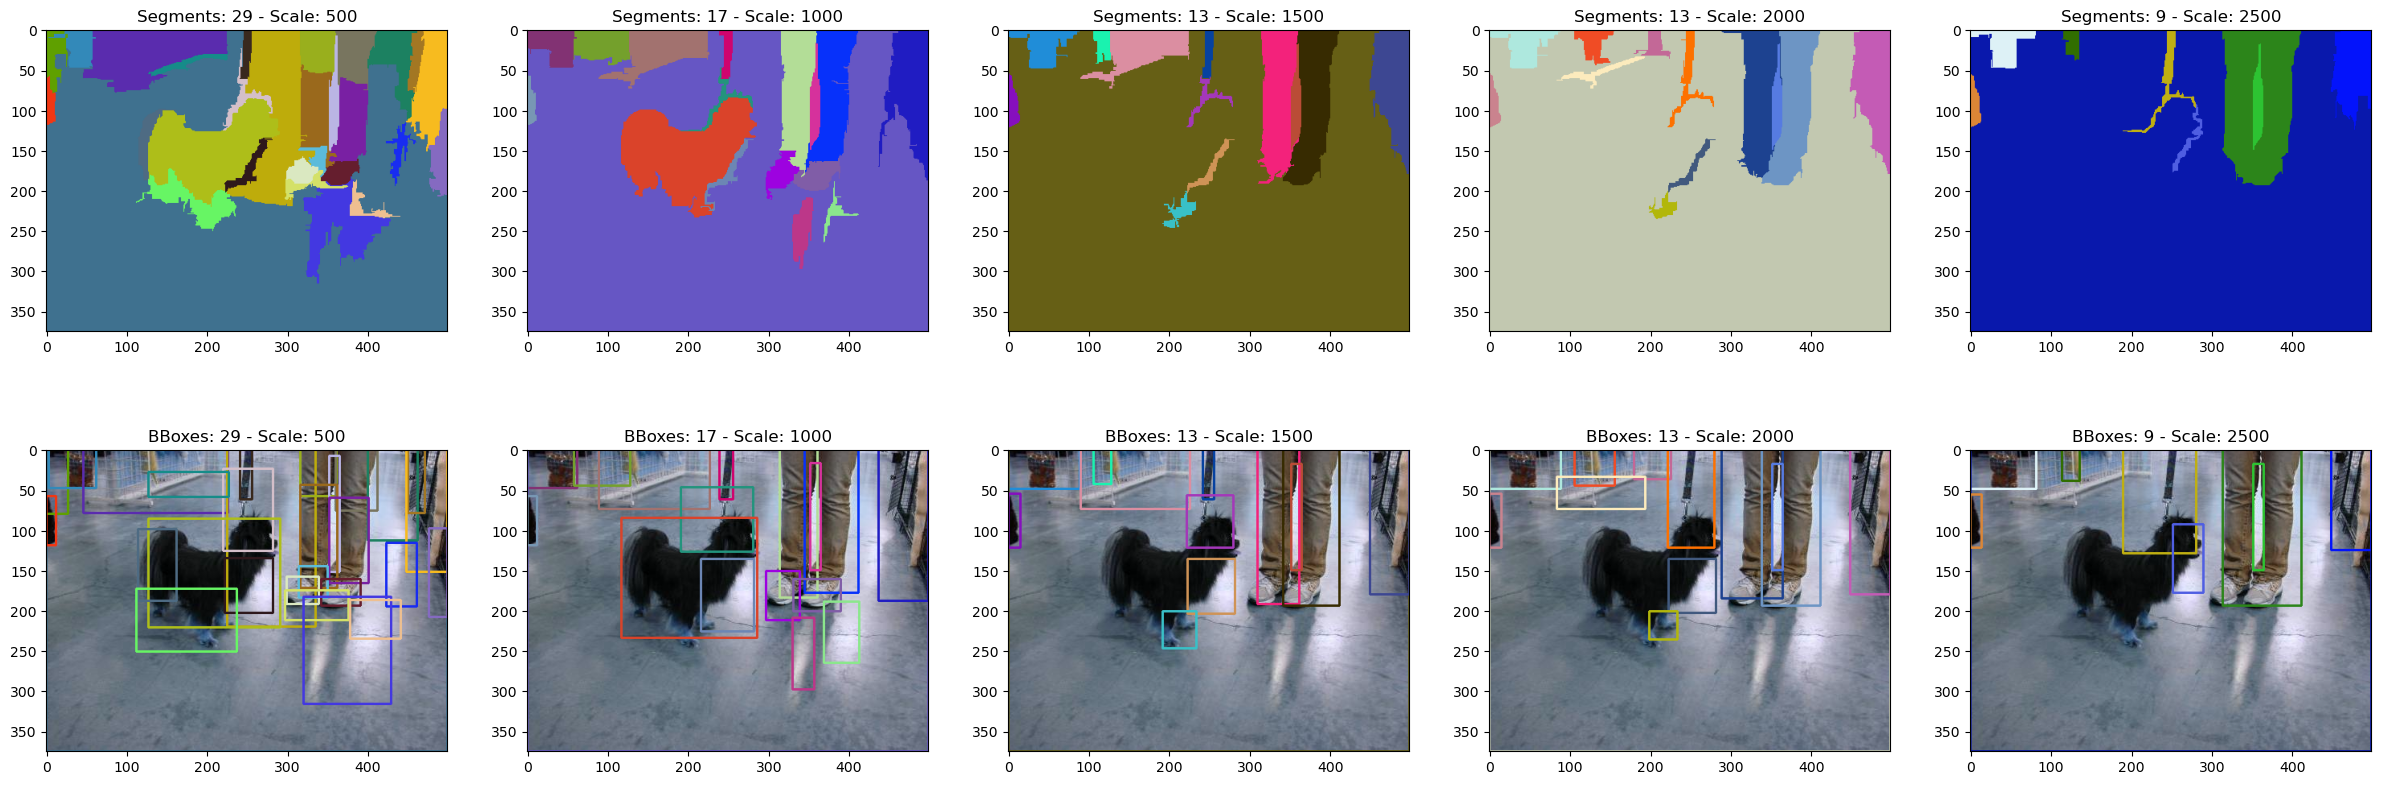

In [32]:
import cv2
import numpy as np
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt

def get_selective_search_segments(
    image: np.ndarray,
    scale: float = 500.0,  # Higher means larger segments
    sigma: float = 0.9,    # Width of Gaussian kernel
    min_size: int = 20     # Minimum component size
) -> Tuple[np.ndarray, List[Dict]]:
    """
    Get image segmentations using selective search's underlying segmentation algorithm.
    
    Args:
        image: Input image (BGR format)
        scale: Free parameter. Higher means larger segments
        sigma: Gaussian kernel width
        min_size: Minimum component size
        
    Returns:
        Tuple containing:
        - Segmentation map (labeled image where each segment has unique integer)
        - List of segment information dictionaries
    """
    # Convert to float32
    float_img = np.float32(image)
    
    # Initialize segmentation
    seg = cv2.ximgproc.segmentation.createGraphSegmentation(
        sigma=sigma,
        k=scale,
        min_size=min_size
    )
    
    # Perform segmentation
    labels = seg.processImage(float_img)
    
    # Get unique segments
    unique_labels = np.unique(labels)
    
    # Process each segment
    segments = []
    for label in unique_labels:
        # Create mask for this segment
        mask = (labels == label).astype(np.uint8)
        
        # Get bounding box
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            x, y, w, h = cv2.boundingRect(contours[0])
            
            # Get segment properties
            segment_info = {
                'label': int(label),
                'mask': mask,
                'bbox': (x, y, w, h),
                'area': np.sum(mask),
                'mean_color': np.mean(image[mask > 0], axis=0)
            }
            
            segments.append(segment_info)
    
    return labels, segments

def visualize_segments(
    image: np.ndarray,
    labels: np.ndarray,
    segments: List[Dict],
    max_vis: int = 5,
    add_labels: bool = False
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Visualize the segmentation results with colored segments and bounding boxes.
    
    Args:
        image: Original image
        labels: Segmentation map
        segments: List of segment information
        max_vis: Maximum number of segments to visualize
        
    Returns:
        Tuple containing:
        - colored_segments: Image with each segment colored differently
        - bbox_image: Original image with bounding boxes drawn
    """
    # Create random colors for visualization
    n_segments = len(segments)
    colors = np.random.randint(0, 255, (n_segments, 3), dtype=np.uint8)
    
    # Create colored segmentation map
    colored_segments = np.zeros_like(image)
    for i, segment in enumerate(segments):
        colored_segments[labels == segment['label']] = colors[i]
    
    # Create image with bounding boxes
    bbox_image = image.copy()
    
    # Draw bounding boxes for max_vis segments
    for i, segment in enumerate(segments[:max_vis]):
        if i >= max_vis:
            break
            
        # Get bounding box coordinates
        x, y, w, h = segment['bbox']
        
        # Draw rectangle with the same color as segment
        color = tuple(map(int, colors[i]))  # Convert to tuple for cv2.rectangle
        cv2.rectangle(bbox_image, (x, y), (x + w, y + h), color, 2)
        
        if add_labels:
            # Optionally add label
            label_text = f"Segment {i+1}"
            cv2.putText(bbox_image, label_text, (x, y-5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return colored_segments, bbox_image


# Read image
image = cv2.imread('/home/ben/data/dogs-vs-cats/train/dog.1000.jpg')

if image is None:
    raise ValueError("Could not read the image")

fig, ax = plt.subplots(ncols=5, nrows=2, figsize=(30, 10))

for i in range(5):
    # Get segmentation
    scale = 500*(i+1)
    labels, segments = get_selective_search_segments(image, scale=scale, min_size=500)
    num_segments = len(segments)
    # Visualize results
    colored_segs, bbox_image = visualize_segments(image, labels, segments, max_vis=num_segments)
    ax[0, i].imshow(colored_segs)
    ax[0, i].set_title(f"Segments: {num_segments} - Scale: {scale}")
    ax[1, i].imshow(bbox_image)
    ax[1, i].set_title(f"BBoxes: {num_segments} - Scale: {scale}")

plt.show()

In [31]:
#| echo: false

for i in range(5):
    scale = 500*(i+1)
    labels, segments = get_selective_search_segments(image, scale=scale, min_size=500)
    num_segments = len(segments)
    colored_segs, bbox_image = visualize_segments(image, labels, segments, max_vis=len(segments))


    # Save the images
    cv2.imwrite(f"./img/selective_search/segment_{scale}.png", colored_segs)
    cv2.imwrite(f"./img/selective_search/bbox_{scale}.png", bbox_image)

# R-CNN

- [R-CNN](https://arxiv.org/pdf/1311.2524) (Regions with Convolutional Neural Networks, circa 2014) can be described as a three-stage process
    1. Region Proposal with Selective Search - Generate a set of bounding boxes
    2. Feature Extraction with CNN - Extract features from the bounding boxes
    3. Classification - Classify the objects within the bounding boxes and perform non-maximum suppression

- Selective Search: Generates ~2000 region proposals per image
- CNN Feature Extraction: Uses AlexNet to extract features from each region proposal
- Laid foundational work for subsequent detection models


## R-CNN Workflow

![](./img/r-cnn.png)

## Non-Maximum Suppression (NMS) Outline  

- **Purpose**: Reduces redundant detections by keeping only the most confident bounding boxes.  
- **Use Case**: Common in object detection to filter overlapping boxes predicting the same object.  
- **Steps**:  
  1. **Sort** bounding boxes by confidence score (highest to lowest).  
  2. **Select** the highest-confidence box and remove it from the list.  
  3. **Compute IoU (Intersection over Union)** between this box and remaining boxes.  
  4. **Suppress** boxes with IoU above a threshold (typically 0.3–0.5).  
  5. **Repeat** for the next highest-confidence box until no boxes remain.  
- **Variants**:  
  - **Soft-NMS**: Decays confidence scores instead of discarding overlapping boxes.  
  - **Class-wise NMS**: Applied separately per object class in multi-class detection.  
- **Challenges**:  
  - Sensitive to IoU threshold selection.  
  - Can remove close but distinct objects in crowded scenes.  
- **Optimizations**:  
  - Faster implementations using sorting and indexing (e.g., GPU-based NMS).

## Non-Maximum Suppression

![](./img/non-max-suppression.png)

# Fast R-CNN

- [Fast R-CNN](https://arxiv.org/pdf/1504.08083) (circa 2015) builds on the R-CNN workflow
    - Improves accuracy and reduces training time over R-CNN
- Processes an entire image at once as opposed to R-CNN which processed each region proposal separately
- Key innovation: ROI Pooling Layer
    - Replaces the resizing of region proposals which occur in R-CNN
    - Efficiently processes region proposals of different sizes into a fixed size.

![](./img/fast-r-cnn-diagram.png)

## Fast R-CNN Workflow

![](./img/fast-r-cnn.png)

## RoI Pooling

![](./img/roi-pooling.png)

## Fast R-CNN Training

![](./img/fast-r-cnn-training.png)

# Study Guide

## Object Detection Fundamentals

**Topics to review:**

- What object detection predicts (boxes + class scores)
- Typical pipeline: proposals, classification, box refinement
- Common failure modes: duplicate boxes, mis-localization, class confusion

**Example questions:**

- What is the difference between image classification and object detection?
- Why do detectors often predict many overlapping boxes?

## Intersection over Union (IoU)

**Topics to review:**

- IoU definition and how it measures overlap
- IoU thresholds for positives/negatives
- Why IoU is used for evaluation and NMS

**Example questions:**

- How do you compute IoU for two boxes?
- What does a higher IoU mean in detection?

## Selective Search

**Topics to review:**

- Purpose of region proposals
- How selective search groups regions based on similarity
- Trade-offs: accuracy vs speed

**Example questions:**

- Why do we need region proposals in early R-CNN pipelines?
- What is a downside of selective search?

## Non-Maximum Suppression (NMS)

**Topics to review:**

- Why NMS is needed (duplicate boxes)
- How NMS uses IoU and confidence scores
- Effects of changing the IoU threshold

**Example questions:**

- What happens if the NMS threshold is too high or too low?
- Why does NMS keep only the highest-score box in an overlap group?

## R-CNN

**Topics to review:**

- R-CNN pipeline: proposals -> CNN features -> classifier + regressor
- Computational cost and why it is slow

**Example questions:**

- What are the main steps in R-CNN?
- Why is R-CNN slower than later variants?

## Fast R-CNN

**Topics to review:**

- How Fast R-CNN shares convolutional features
- ROI Pooling (high-level idea)
- Why Fast R-CNN is faster than R-CNN

**Example questions:**

- What is the main efficiency improvement in Fast R-CNN?
- Why does sharing features reduce compute?



<!-- ## 4. Evaluation Metrics

### Key Metrics:
1. Intersection over Union (IoU)
2. Precision and Recall
3. Average Precision (AP)
4. Mean Average Precision (mAP)

### COCO Metrics:
- AP@[.5:.95]
- AP@.50
- AP@.75
- AP_small/medium/large

## 5. Training Considerations

### Data Preparation:
- Dataset collection and annotation
- Data augmentation techniques
- Handling class imbalance

### Loss Functions:
1. Classification Loss
2. Localization Loss
3. Objectness Loss

### Optimization Strategies:
- Learning rate scheduling
- Transfer learning
- Multi-scale training

## 6. Recent Trends and Future Directions

### Current Research Areas:
1. Transformer-based Detectors (DETR, Swin)
2. Self-supervised Learning
3. Few-shot Object Detection
4. Real-time Detection Optimization

### Emerging Applications:
- Autonomous Vehicles
- Medical Imaging
- Surveillance Systems
- Retail Analytics

## References and Further Reading

1. Girshick, R. (2015). Fast R-CNN
2. Redmon, J. et al. (2016). You Only Look Once: Unified, Real-Time Object Detection
3. Lin, T. Y. et al. (2017). Focal Loss for Dense Object Detection
4. Carion, N. et al. (2020). End-to-End Object Detection with Transformers -->